gg

In [ ]:
import matplotlib.pyplot as plt
import os
import torch
import numpy as np
from matplotlib.colors import LinearSegmentedColormap


from models.MLP import MLP
from models.KAN import KAN

In [48]:
# Set up paths
MODEL_DIR = os.path.join("..", "src", "models", "saved") 
os.makedirs(MODEL_DIR, exist_ok=True)

MLP_PATH = os.path.join(MODEL_DIR, "mlp.pth")
KAN_PATH = os.path.join(MODEL_DIR, "kan.pth")
MLP_LOSSES_PATH = os.path.join(MODEL_DIR, "mlp_losses.pt")
KAN_LOSSES_PATH = os.path.join(MODEL_DIR, "kan_losses.pt")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:

if os.path.exists(MLP_PATH) and os.path.exists(KAN_PATH):
    print("\n Loading pre-trained models...")
    mlp = MLP(hidden=64).to(device)
    mlp.load_state_dict(torch.load(MLP_PATH, map_location=device))
    
    # Ensure hidden_dim matches your trained architecture
    kan = KAN(in_dim=2, hidden_dim=5, out_dim=1, hidden_per_uni=8).to(device)
    kan.load_state_dict(torch.load(KAN_PATH, map_location=device))
    
    # Load saved losses for plotting
    mlp_losses = torch.load(MLP_LOSSES_PATH, weights_only=True)
    mlp_train_loss = mlp_losses['train']
    mlp_test_loss = mlp_losses['test']
    
    kan_losses = torch.load(KAN_LOSSES_PATH, weights_only=True)
    kan_train_loss = kan_losses['train']
    kan_test_loss = kan_losses['test']

### LOAD TEST DATA 
x_test = torch.load("../data/x_test_data_hard.pt", weights_only=True).to(device)
y_test = torch.load("../data/y_test_data_hard.pt", weights_only=True).to(device)


 Loading pre-trained models...


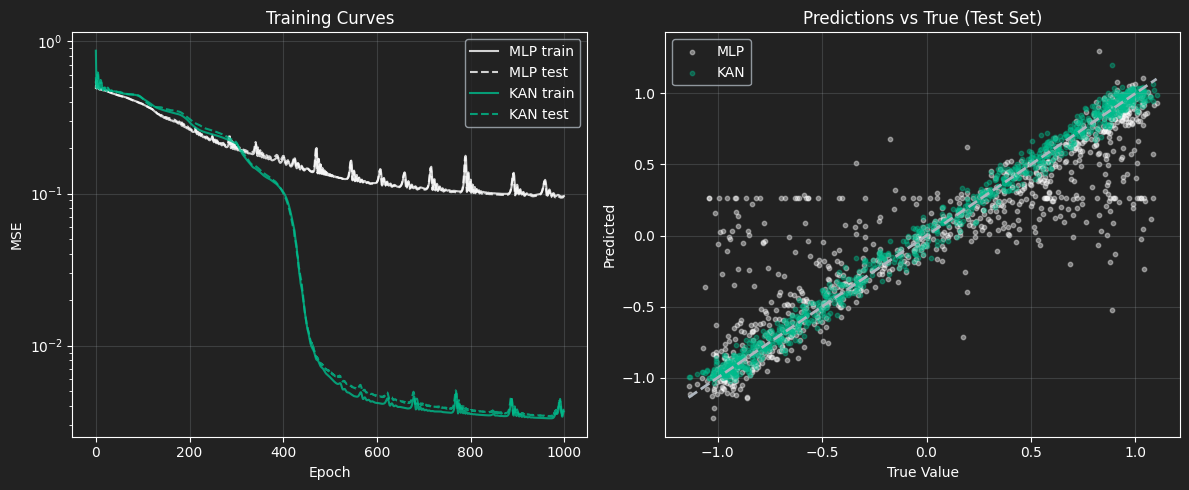

In [ ]:
# METRICS PLOTS

# Themes
BG_COLOR = '#222222'
ACCENT = '#00bc8c'
TEXT = '#ffffff'
MUTED = '#adb5bd'

plt.rcParams.update({
    'text.color': TEXT, 'axes.labelcolor': TEXT,
    'xtick.color': TEXT, 'ytick.color': TEXT,
    'axes.facecolor': BG_COLOR, 'axes.edgecolor': TEXT
})

fig = plt.figure(figsize=(12, 5), facecolor=BG_COLOR)

plt.subplot(1, 2, 1)
plt.plot(mlp_train_loss, label="MLP train", alpha=0.8, color=TEXT) 
plt.plot(mlp_test_loss, label="MLP test", alpha=0.8, color=TEXT, linestyle='--')
plt.plot(kan_train_loss, label="KAN train", alpha=0.8, color=ACCENT) 
plt.plot(kan_test_loss, label="KAN test", alpha=0.8, color=ACCENT, linestyle='--')
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training Curves")
plt.legend(facecolor=BG_COLOR, edgecolor=MUTED)
plt.grid(True, alpha=0.2, color=MUTED) # Muted grid lines

plt.subplot(1, 2, 2)

with torch.no_grad():
    mlp_pred = mlp(x_test).cpu().numpy().flatten()
    kan_pred = kan(x_test).cpu().numpy().flatten()
    y_true = y_test.cpu().numpy().flatten()

plt.scatter(y_true, mlp_pred, alpha=0.4, label="MLP", s=10, color=TEXT)
plt.scatter(y_true, kan_pred, alpha=0.4, label="KAN", s=10, color=ACCENT)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], color=MUTED, linestyle="--", lw=2)
plt.xlabel("True Value")
plt.ylabel("Predicted")
plt.title("Predictions vs True (Test Set)")
plt.legend(facecolor=BG_COLOR, edgecolor=MUTED)
plt.grid(True, alpha=0.2, color=MUTED)

plt.tight_layout()
plt.show()


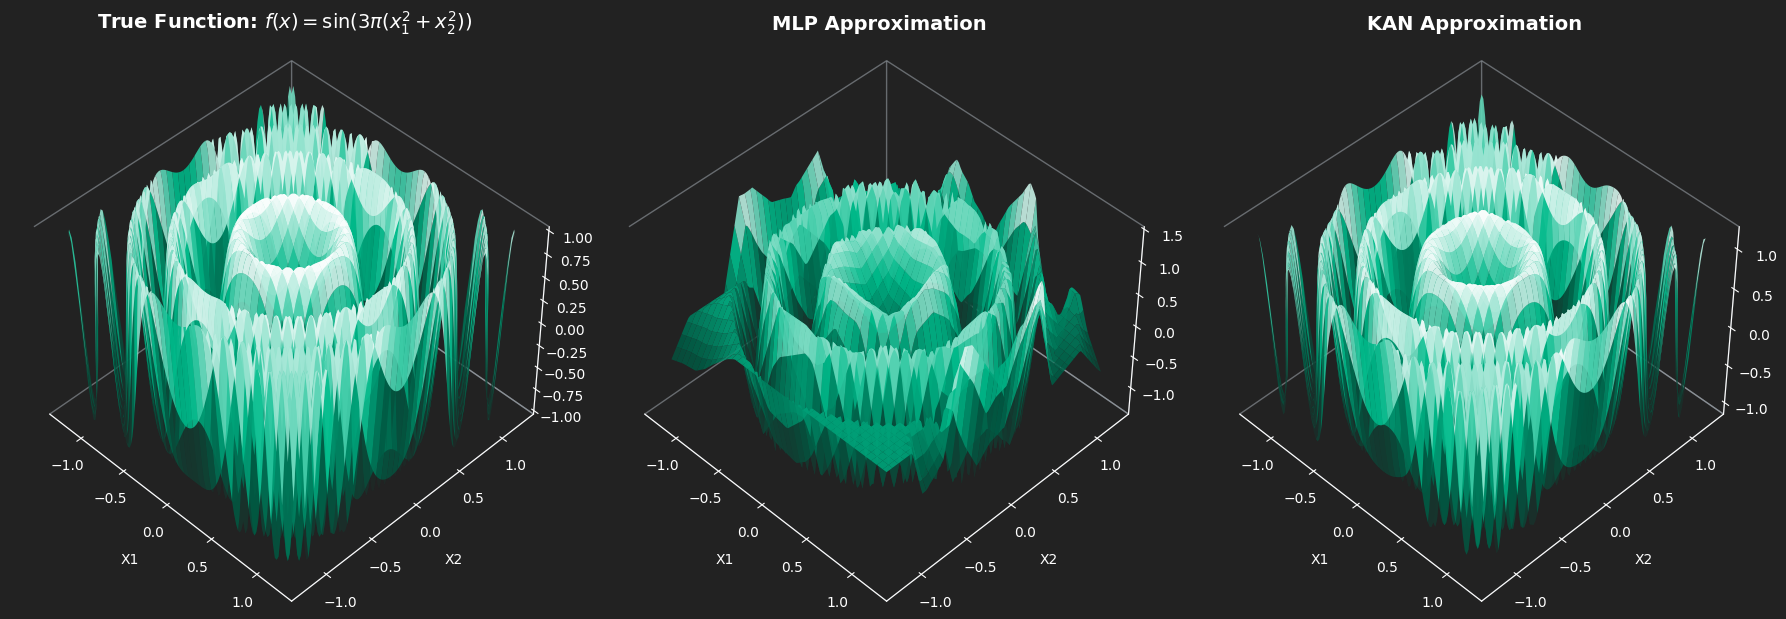


Evaluation Complete.
KAN parameters: 375
MLP parameters: 4417


In [ ]:

# 3D SURFACE PLOTS 

grid_size = 120 
x1 = np.linspace(-1.2, 1.2, grid_size)
x2 = np.linspace(-1.2, 1.2, grid_size)
X1, X2 = np.meshgrid(x1, x2)
X_grid = torch.tensor(np.c_[X1.ravel(), X2.ravel()], dtype=torch.float32).to(device)

theme_cmap = LinearSegmentedColormap.from_list(
    "theme_cmap",
    ["#222222", "#005a43", "#00bc8c", "#ffffff"] 
)

with torch.no_grad():
    radius_squared = X_grid[:, 0]**2 + X_grid[:, 1]**2
    Y_true = torch.sin(3 * torch.pi * radius_squared)
    Y_true = Y_true.cpu().numpy().reshape(grid_size, grid_size)

with torch.no_grad():
    Y_mlp = mlp(X_grid).cpu().numpy().reshape(grid_size, grid_size)
    Y_kan = kan(X_grid).cpu().numpy().reshape(grid_size, grid_size)

fig = plt.figure(figsize=(18, 6), facecolor='#222222')


def format_3d_ax(ax, title):
    ax.set_facecolor('#222222')
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    
    ax.xaxis.pane.set_edgecolor('#adb5bd')
    ax.yaxis.pane.set_edgecolor('#adb5bd')
    ax.zaxis.pane.set_edgecolor('#adb5bd')
    
    ax.grid(False)
    ax.tick_params(colors='#ffffff')
    ax.set_xlabel('X1', color='#ffffff', labelpad=10)
    ax.set_ylabel('X2', color='#ffffff', labelpad=10)
    ax.set_zlabel('Y',  color='#ffffff', labelpad=10)
    ax.set_title(title, color='#ffffff', pad=20, fontsize=14, fontweight='bold')
    ax.view_init(elev=45, azim=-45)
    
    for spine in ax.spines.values():
        spine.set_edgecolor('#ffffff')

ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X1, X2, Y_true, cmap=theme_cmap, alpha=0.9, linewidth=0, antialiased=True)
format_3d_ax(ax1, r"True Function: $f(x) = \sin(3\pi(x_1^2 + x_2^2))$")

# MLP approximation
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(X1, X2, Y_mlp, cmap=theme_cmap, alpha=0.9, linewidth=0, antialiased=True)
format_3d_ax(ax2, "MLP Approximation")

# KAN approximation
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(X1, X2, Y_kan, cmap=theme_cmap, alpha=0.9, linewidth=0, antialiased=True)
format_3d_ax(ax3, "KAN Approximation")

plt.tight_layout()
plt.show()

print("\nEvaluation Complete.")
print(f"KAN parameters: {sum(p.numel() for p in kan.parameters())}")
print(f"MLP parameters: {sum(p.numel() for p in mlp.parameters())}")

MLP Extrapolation MSE (>|1.2|): 1.8749
KAN Extrapolation MSE (>|1.2|): 0.2929
MLP Interpolation MSE (<=|1.2|): 0.1063
KAN Interpolation MSE (<=|1.2|): 0.0014


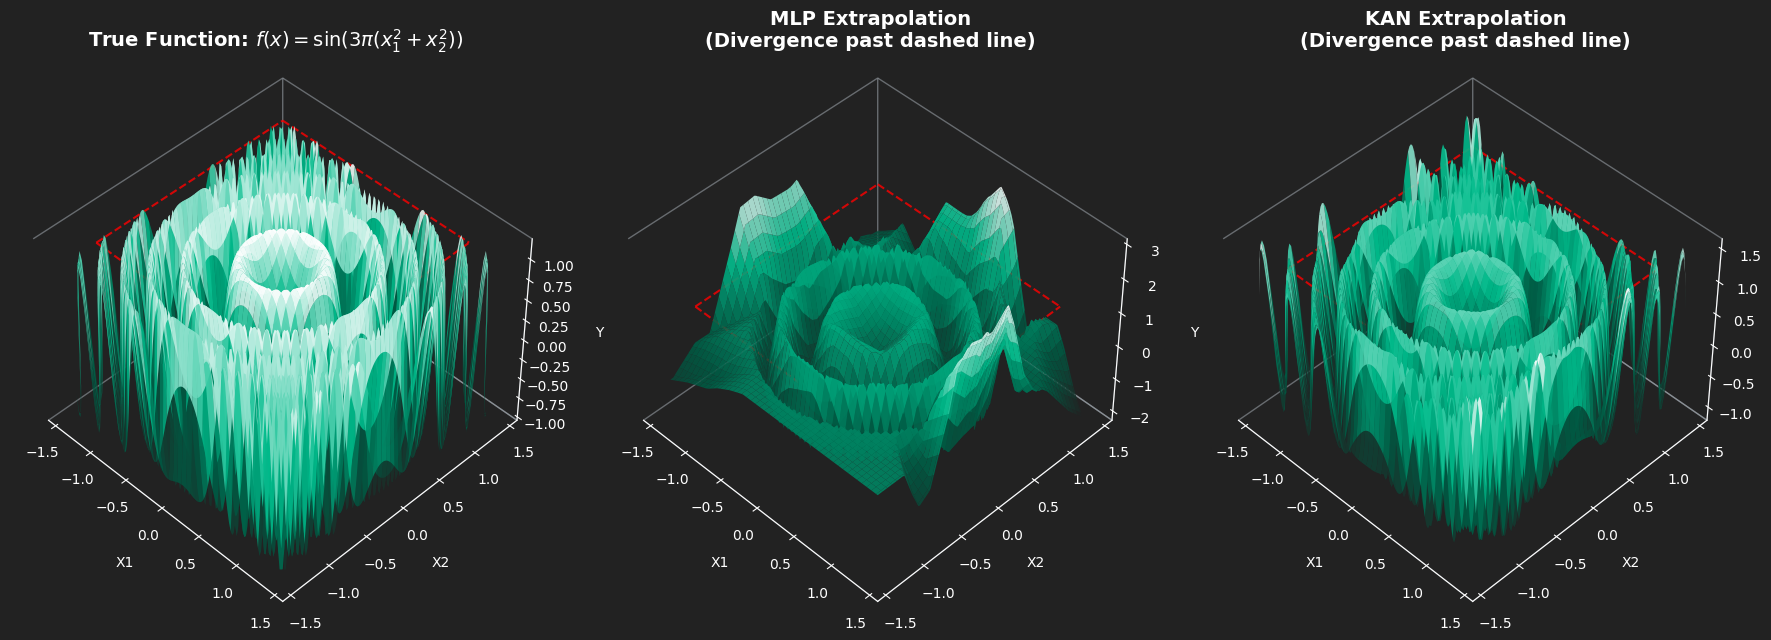

In [ ]:

# EXTRAPOLATION DATA & MSE 
grid_size_ext = 140 # Increased grid size for larger domain
limit_ext = 1.4
limit_train = 1.2

x1_ext = np.linspace(-limit_ext, limit_ext, grid_size_ext)
x2_ext = np.linspace(-limit_ext, limit_ext, grid_size_ext)
X1_ext, X2_ext = np.meshgrid(x1_ext, x2_ext)
X_grid_ext = torch.tensor(np.c_[X1_ext.ravel(), X2_ext.ravel()], dtype=torch.float32).to(device)

# True function on expanded grid
with torch.no_grad():
    radius_squared_ext = X_grid_ext[:, 0]**2 + X_grid_ext[:, 1]**2
    Y_true_flat = torch.sin(3 * torch.pi * radius_squared_ext)
    Y_true_ext = Y_true_flat.cpu().numpy().reshape(grid_size_ext, grid_size_ext)

# Model predictions on expanded grid
with torch.no_grad():
    try:
        Y_mlp_flat = mlp(X_grid_ext).squeeze()
        Y_mlp_ext = Y_mlp_flat.cpu().numpy().reshape(grid_size_ext, grid_size_ext)
    except Exception as e:
        print(f"MLP evaluation failed: {e}")
        
    try:
        Y_kan_flat = kan(X_grid_ext).squeeze()
        Y_kan_ext = Y_kan_flat.cpu().numpy().reshape(grid_size_ext, grid_size_ext)
    except Exception as e:
        print(f"KAN evaluation failed (likely out-of-bounds B-spline grid): {e}")

# Calculate isolated Extrapolation MSE
# Mask: True if point is OUTSIDE the original [-1.2, 1.2] square
extrap_mask = (torch.abs(X_grid_ext[:, 0]) > limit_train) | (torch.abs(X_grid_ext[:, 1]) > limit_train)

if 'Y_mlp_flat' in locals():
    mse_mlp_extrap = torch.nn.functional.mse_loss(Y_mlp_flat[extrap_mask], Y_true_flat[extrap_mask])
    print(f"MLP Extrapolation MSE (>|1.2|): {mse_mlp_extrap.item():.4f}")

if 'Y_kan_flat' in locals():
    mse_kan_extrap = torch.nn.functional.mse_loss(Y_kan_flat[extrap_mask], Y_true_flat[extrap_mask])
    print(f"KAN Extrapolation MSE (>|1.2|): {mse_kan_extrap.item():.4f}")

train_mask = ~extrap_mask

if 'Y_mlp_flat' in locals():
    mse_mlp_train = torch.nn.functional.mse_loss(Y_mlp_flat[train_mask], Y_true_flat[train_mask])
    print(f"MLP Interpolation MSE (<=|1.2|): {mse_mlp_train.item():.4f}")

if 'Y_kan_flat' in locals():
    mse_kan_train = torch.nn.functional.mse_loss(Y_kan_flat[train_mask], Y_true_flat[train_mask])
    print(f"KAN Interpolation MSE (<=|1.2|): {mse_kan_train.item():.4f}")


# 3D SURFACE PLOTS
theme_cmap = LinearSegmentedColormap.from_list(
    "theme_cmap",
    ["#222222", "#005a43", "#00bc8c", "#ffffff"]
)

fig = plt.figure(figsize=(18, 6), facecolor='#222222')

def format_3d_ax(ax, title):
    ax.set_facecolor('#222222')
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    
    ax.xaxis.pane.set_edgecolor('#adb5bd')
    ax.yaxis.pane.set_edgecolor('#adb5bd')
    ax.zaxis.pane.set_edgecolor('#adb5bd')
    
    ax.grid(False)
    ax.tick_params(colors='#ffffff')
    ax.set_xlabel('X1', color='#ffffff', labelpad=10)
    ax.set_ylabel('X2', color='#ffffff', labelpad=10)
    ax.set_zlabel('Y',  color='#ffffff', labelpad=10)
    ax.set_title(title, color='#ffffff', pad=20, fontsize=14, fontweight='bold')
    ax.view_init(elev=45, azim=-45)
    
    for spine in ax.spines.values():
        spine.set_edgecolor('#ffffff')

def plot_training_boundary(ax):
    t = np.linspace(-limit_train, limit_train, 10)
    z_min, z_max = -1.2, 1.2
    
    ax.plot([-limit_train, limit_train], [-limit_train, -limit_train], [z_max, z_max], color='red', linestyle='--', alpha=0.8, linewidth=1.5)
    ax.plot([-limit_train, limit_train], [limit_train, limit_train], [z_max, z_max], color='red', linestyle='--', alpha=0.8, linewidth=1.5)
    ax.plot([-limit_train, -limit_train], [-limit_train, limit_train], [z_max, z_max], color='red', linestyle='--', alpha=0.8, linewidth=1.5)
    ax.plot([limit_train, limit_train], [-limit_train, limit_train], [z_max, z_max], color='red', linestyle='--', alpha=0.8, linewidth=1.5)

# True Function
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X1_ext, X2_ext, Y_true_ext, cmap=theme_cmap, alpha=0.9, linewidth=0, antialiased=True)
plot_training_boundary(ax1)
format_3d_ax(ax1, r"True Function: $f(x) = \sin(3\pi(x_1^2 + x_2^2))$")

# MLP Approximation
if 'Y_mlp_ext' in locals():
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.plot_surface(X1_ext, X2_ext, Y_mlp_ext, cmap=theme_cmap, alpha=0.9, linewidth=0, antialiased=True)
    plot_training_boundary(ax2)
    format_3d_ax(ax2, "MLP Extrapolation\n(Divergence past dashed line)")

# KAN Approximation
if 'Y_kan_ext' in locals():
    ax3 = fig.add_subplot(133, projection='3d')
    ax3.plot_surface(X1_ext, X2_ext, Y_kan_ext, cmap=theme_cmap, alpha=0.9, linewidth=0, antialiased=True)
    plot_training_boundary(ax3)
    format_3d_ax(ax3, "KAN Extrapolation\n(Divergence past dashed line)")

plt.tight_layout()
plt.show()